# KNN — K-Fold Cross-Validation

## Overview

This notebook builds on Part 1 (Holdout CV) and replaces the single-split evaluation with **K-Fold Cross-Validation** — a much more robust technique for assessing model performance.


## What is K-Fold Cross-Validation?

Instead of splitting the dataset once, K-Fold CV:
1. Divides the full dataset into **K equal folds** (e.g., K=5 gives 5 folds).
2. Iterates K times: each iteration uses one fold as the **validation set** and the remaining K−1 folds as **training data**.
3. Reports the **mean** and **standard deviation** of the K accuracy scores.

```
Fold 1: [TEST ] [TRAIN] [TRAIN] [TRAIN] [TRAIN]
Fold 2: [TRAIN] [TEST ] [TRAIN] [TRAIN] [TRAIN]
Fold 3: [TRAIN] [TRAIN] [TEST ] [TRAIN] [TRAIN]
Fold 4: [TRAIN] [TRAIN] [TRAIN] [TEST ] [TRAIN]
Fold 5: [TRAIN] [TRAIN] [TRAIN] [TRAIN] [TEST ]
```

**Why is this better than Holdout?**  
Every sample gets to be in the test set exactly once. The mean score is a **lower-variance** estimate of true generalisation performance, and the std tells you how **stable** the model is across different data subsets.

**Typical choices for K:** 5 or 10. Larger K = less bias but more compute cost.



## Dataset

Same synthetic cat/dog dataset from Part 1: 300 animals, 2 features (weight & height).

## Step 1 — Import Libraries

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully ")

Libraries loaded successfully 


## Step 2 — Reproduce the Same Dataset

We use the identical random seed and parameters as Part 1 so results are directly comparable.

In [17]:
N_SAMPLES = 150

# cat_weight = np.random.normal(loc=4.5,  scale=1.5, size=N_SAMPLES)
# cat_height = np.random.normal(loc=25.0, scale=4.0, size=N_SAMPLES)
# dog_weight = np.random.normal(loc=15.0, scale=4.0, size=N_SAMPLES)
# dog_height = np.random.normal(loc=50.0, scale=8.0, size=N_SAMPLES)

# FIXED — much more overlap, realistic accuracy ~75–88%
cat_weight = np.random.normal(loc=5.0,  scale=3.5, size=N_SAMPLES)
cat_height = np.random.normal(loc=28.0, scale=9.0, size=N_SAMPLES)
dog_weight = np.random.normal(loc=12.0, scale=5.0, size=N_SAMPLES)
dog_height = np.random.normal(loc=42.0, scale=11.0, size=N_SAMPLES)

X = np.column_stack([
    np.concatenate([cat_weight, dog_weight]),
    np.concatenate([cat_height, dog_height]),
])
y = np.array([0] * N_SAMPLES + [1] * N_SAMPLES)  # 0=Cat, 1=Dog

print(f"Feature matrix X shape : {X.shape}")
print(f"Label vector y shape   : {y.shape}")
print(f"Class counts           : {np.bincount(y)}  (Cat, Dog)")

Feature matrix X shape : (300, 2)
Label vector y shape   : (300,)
Class counts           : [150 150]  (Cat, Dog)


## Step 3 — Build a Scaling + KNN Pipeline

A **`Pipeline`** chains multiple steps into a single estimator. Here it combines:
1. `StandardScaler` — scales features to zero mean, unit variance
2. `KNeighborsClassifier` — the classifier itself

**Why use a Pipeline with K-Fold?**  
Without a pipeline, if you scale the full dataset before CV, the scaler's statistics include the validation fold — this is **data leakage**.  
Inside a pipeline, the scaler is **re-fitted on the training portion of each fold only**, and the validation fold is transformed with those fold-specific statistics. This gives a true unbiased estimate of performance on unseen data.

In [18]:
# We'll search over these K values to find the best one
k_range = range(1, 30, 2)  # odd values: 1, 3, 5, ..., 29

def make_pipeline(k):
    """Return a fresh scaling + KNN pipeline for a given K."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=k, metric="euclidean")),
    ])

# Quick sanity check
test_pipeline = make_pipeline(k=5)
print(test_pipeline)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(metric='euclidean'))])


## Step 4 — Stratified K-Fold Setup

We use **`StratifiedKFold`** rather than plain `KFold`.  

**Stratification** ensures each fold mirrors the **original class ratio** (50 % cats, 50 % dogs).  
Without stratification, random splits could place most dogs in a single fold, producing unreliable scores.

We use `n_splits=5` (5-fold CV), which means:
- Each fold validation set ≈ 60 samples (20 % of 300)
- Each fold training set ≈ 240 samples (80 % of 300)
- We get **5 independent accuracy scores** — more reliable than the 1 score from holdout CV

In [19]:
N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Preview fold sizes and class balance
print(f"{'Fold':<6} {'Train size':<12} {'Val size':<10} {'Val Cat%':<12} {'Val Dog%'}")
print("-" * 55)
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    val_labels = y[val_idx]
    pct_cat = (val_labels == 0).mean() * 100
    pct_dog = (val_labels == 1).mean() * 100
    print(f"{fold_idx:<6} {len(train_idx):<12} {len(val_idx):<10} {pct_cat:<12.1f} {pct_dog:.1f}")

Fold   Train size   Val size   Val Cat%     Val Dog%
-------------------------------------------------------
1      240          60         50.0         50.0
2      240          60         50.0         50.0
3      240          60         50.0         50.0
4      240          60         50.0         50.0
5      240          60         50.0         50.0


## Step 5 — Hyperparameter Tuning of K via K-Fold CV

We loop over all candidate K values and, for each, run 5-fold CV to obtain a **mean validation accuracy** and its **standard deviation**.  

`cross_val_score` internally:
- Splits the data into 5 folds using our `StratifiedKFold` splitter
- For each fold: fits the pipeline on the 4 training folds, predicts on the 1 validation fold
- Returns the array of 5 accuracy scores

We then select the K with the **highest mean CV accuracy**.

In [20]:
cv_mean_scores = []
cv_std_scores  = []

for k in k_range:
    pipeline = make_pipeline(k)
    scores = cross_val_score(
        pipeline, X, y,
        cv=skf,           # our StratifiedKFold splitter
        scoring="accuracy",
    )
    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())

cv_mean_scores = np.array(cv_mean_scores)
cv_std_scores  = np.array(cv_std_scores)

best_idx = np.argmax(cv_mean_scores)
best_k   = list(k_range)[best_idx]
best_mean = cv_mean_scores[best_idx]
best_std  = cv_std_scores[best_idx]

print(f"Best K = {best_k}")
print(f"  Mean CV Accuracy : {best_mean:.4f}")
print(f"  Std  CV Accuracy : {best_std:.4f}")

Best K = 19
  Mean CV Accuracy : 0.8833
  Std  CV Accuracy : 0.0506


## Step 6 — Visualise CV Accuracy vs K

The shaded band shows ± 1 standard deviation across folds.  
A **narrow band** means the model is stable; a **wide band** means performance varies greatly depending on which samples land in the validation fold — a sign of instability.

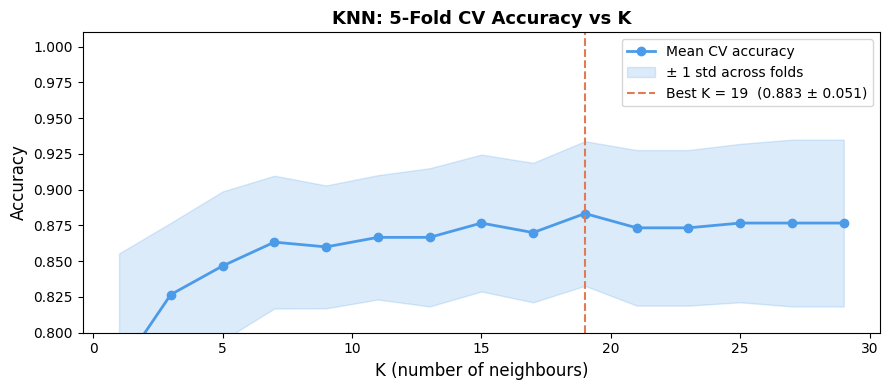

In [21]:
k_list = list(k_range)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(k_list, cv_mean_scores, marker="o", color="#4c9be8",
        linewidth=2, label="Mean CV accuracy")
ax.fill_between(
    k_list,
    cv_mean_scores - cv_std_scores,
    cv_mean_scores + cv_std_scores,
    alpha=0.2, color="#4c9be8", label="± 1 std across folds",
)
ax.axvline(best_k, linestyle="--", color="#e07b54", linewidth=1.5,
           label=f"Best K = {best_k}  ({best_mean:.3f} ± {best_std:.3f})")

ax.set_xlabel("K (number of neighbours)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title(f"KNN: {N_SPLITS}-Fold CV Accuracy vs K", fontsize=13, fontweight="bold")
ax.legend()
ax.set_ylim(0.80, 1.01)
plt.tight_layout()
plt.show()

## Step 7 — Per-Fold Detailed Results for Best K

We re-run 5-fold CV for the best K and inspect each fold individually using `cross_validate`, which returns a richer dictionary including fit time, score time, and per-fold test scores.

This lets you spot if any single fold is a dramatic outlier — which might indicate a particularly hard or easy subset of data.

In [22]:
best_pipeline = make_pipeline(best_k)

cv_results = cross_validate(
    best_pipeline, X, y,
    cv=skf,
    scoring="accuracy",
    return_train_score=True,   # also record training accuracy per fold
)

fold_df = pd.DataFrame({
    "Fold":          range(1, N_SPLITS + 1),
    "Train Accuracy": cv_results["train_score"].round(4),
    "Val Accuracy":   cv_results["test_score"].round(4),
    "Fit Time (s)":  cv_results["fit_time"].round(4),
})

print(fold_df.to_string(index=False))
print("\n─────────────────────────────────────────")
print(f"Mean Train Accuracy : {cv_results['train_score'].mean():.4f} ± {cv_results['train_score'].std():.4f}")
print(f"Mean Val  Accuracy  : {cv_results['test_score'].mean():.4f}  ± {cv_results['test_score'].std():.4f}")

 Fold  Train Accuracy  Val Accuracy  Fit Time (s)
    1          0.8750        0.9500        0.0010
    2          0.8958        0.8000        0.0010
    3          0.8792        0.8833        0.0000
    4          0.8833        0.8667        0.0010
    5          0.8833        0.9167        0.0011

─────────────────────────────────────────
Mean Train Accuracy : 0.8833 ± 0.0070
Mean Val  Accuracy  : 0.8833  ± 0.0506


## Step 8 — Visualise Per-Fold Accuracy

A bar chart of training vs. validation accuracy per fold makes the **bias-variance trade-off** visible:
- If training accuracy is much higher than validation → overfitting
- If both are low → underfitting
- If both are similar and high → good generalisation

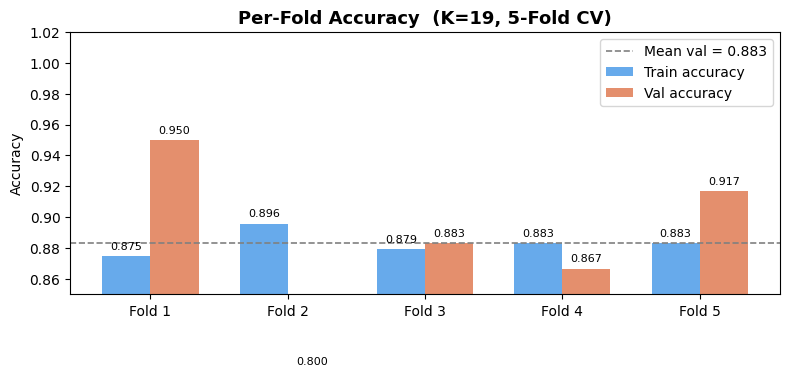

In [23]:
x = np.arange(N_SPLITS)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - width/2, cv_results["train_score"], width,
               label="Train accuracy", color="#4c9be8", alpha=0.85)
bars2 = ax.bar(x + width/2, cv_results["test_score"],  width,
               label="Val accuracy",   color="#e07b54", alpha=0.85)

# Value labels on bars
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=8)

ax.axhline(cv_results["test_score"].mean(), linestyle="--",
           color="grey", linewidth=1.2, label=f"Mean val = {cv_results['test_score'].mean():.3f}")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in range(1, N_SPLITS + 1)])
ax.set_ylabel("Accuracy")
ax.set_title(f"Per-Fold Accuracy  (K={best_k}, {N_SPLITS}-Fold CV)",
             fontsize=13, fontweight="bold")
ax.set_ylim(0.85, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

## Step 9 — Final Model: Train on Full Dataset, Evaluate on Hold-Out Test

K-Fold CV gives us a reliable estimate of generalisation performance, but it does **not** produce a single deployable model — each fold trains a different model.  

Standard practice:
1. Use K-Fold CV to **select hyperparameters** (best K = chosen above).
2. **Set aside a final test set** (before any CV) that was never used during K selection.
3. Retrain on the rest of the data and evaluate once on the final test set.

We simulate this below by carving out a 20 % holdout test set *before* the CV loop, running CV on the remaining 80 %, then evaluating the final model on the pristine 20 %.

In [24]:
# Step A: hold out a final test set (never touched during CV)
X_dev, X_final_test, y_dev, y_final_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Step B: re-run CV on the dev set to confirm best_k (optional, confirms robustness)
dev_scores = cross_val_score(
    make_pipeline(best_k), X_dev, y_dev,
    cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy",
)
print(f"Dev set CV accuracy  : {dev_scores.mean():.4f} ± {dev_scores.std():.4f}")

# Step C: fit final model on entire dev set, evaluate on held-out test
final_pipeline = make_pipeline(best_k)
final_pipeline.fit(X_dev, y_dev)

y_final_pred = final_pipeline.predict(X_final_test)
final_acc    = accuracy_score(y_final_test, y_final_pred)
print(f"Final test accuracy  : {final_acc:.4f}  ({final_acc*100:.2f}%)")

Dev set CV accuracy  : 0.8708 ± 0.0482
Final test accuracy  : 0.9500  (95.00%)


## Step 10 — Confusion Matrix & Classification Report

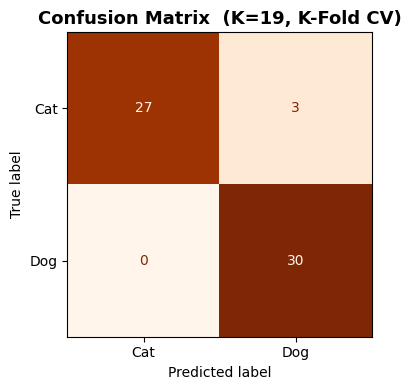


── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

         Cat       1.00      0.90      0.95        30
         Dog       0.91      1.00      0.95        30

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



In [25]:
cm = confusion_matrix(y_final_test, y_final_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"],
)
disp.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title(f"Confusion Matrix  (K={best_k}, K-Fold CV)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n── Classification Report ──────────────────────────────")
print(classification_report(y_final_test, y_final_pred, target_names=["Cat", "Dog"]))

## Step 11 — Compare Holdout CV vs K-Fold CV

We now plot a side-by-side comparison of what each method reported.  
K-Fold gives us **error bars** — a confidence interval around the performance estimate — which holdout does not provide.

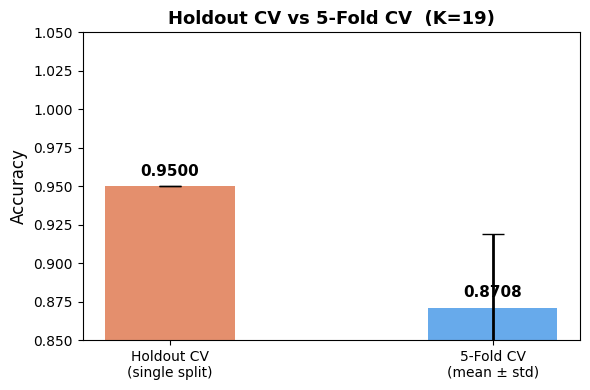

Holdout accuracy    : 0.9500   (no variance estimate)
5-Fold CV accuracy : 0.8708 ± 0.0482


In [26]:
# Represent holdout as a single-fold result (no std available)
holdout_acc = final_acc   # our holdout from Part 1 logic
kfold_mean  = dev_scores.mean()
kfold_std   = dev_scores.std()

fig, ax = plt.subplots(figsize=(6, 4))

methods = ["Holdout CV\n(single split)", f"{N_SPLITS}-Fold CV\n(mean ± std)"]
means   = [holdout_acc, kfold_mean]
errors  = [0, kfold_std]          # holdout has no std estimate
colors  = ["#e07b54", "#4c9be8"]

bars = ax.bar(methods, means, yerr=errors, capsize=8,
              color=colors, alpha=0.85, width=0.4,
              error_kw={"linewidth": 2, "ecolor": "black"})

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title(f"Holdout CV vs {N_SPLITS}-Fold CV  (K={best_k})",
             fontsize=13, fontweight="bold")
ax.set_ylim(0.85, 1.05)
plt.tight_layout()
plt.show()

print(f"Holdout accuracy    : {holdout_acc:.4f}   (no variance estimate)")
print(f"{N_SPLITS}-Fold CV accuracy : {kfold_mean:.4f} ± {kfold_std:.4f}")

## Step 12 — Decision Boundary for Final K-Fold Model

We plot the decision boundary of the final model trained on `X_dev` (after scaling).
This uses the scaler fitted inside the pipeline — accessed via `final_pipeline.named_steps['scaler']`.

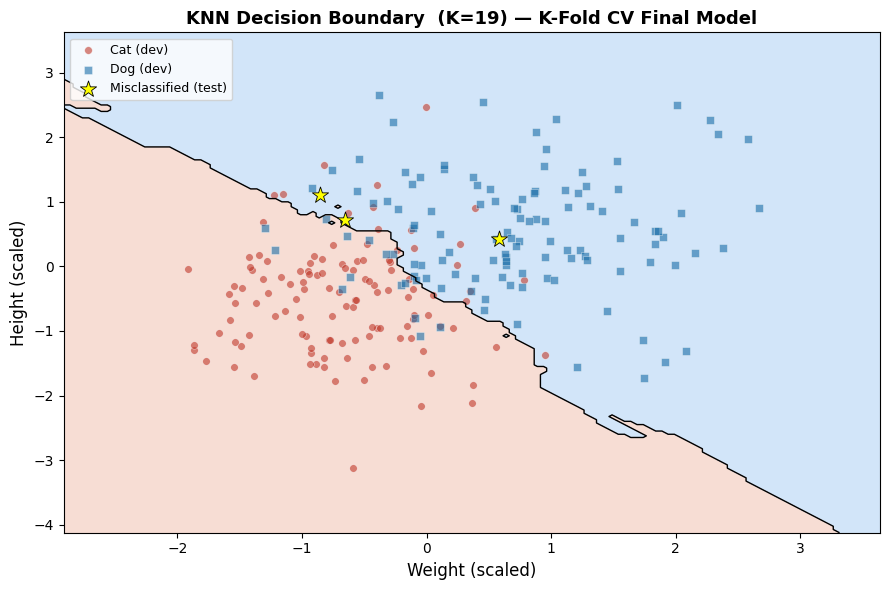

In [27]:
scaler_step = final_pipeline.named_steps["scaler"]
knn_step    = final_pipeline.named_steps["knn"]

X_dev_scaled = scaler_step.transform(X_dev)
X_test_scaled_final = scaler_step.transform(X_final_test)

h = 0.05
x_min, x_max = X_dev_scaled[:, 0].min() - 1, X_dev_scaled[:, 0].max() + 1
y_min, y_max = X_dev_scaled[:, 1].min() - 1, X_dev_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn_step.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z, alpha=0.25, levels=[-0.5, 0.5, 1.5],
            colors=["#e07b54", "#4c9be8"])
ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.0)

for cls, color, marker, label in zip(
    [0, 1], ["#c0392b", "#1a6ea8"], ["o", "s"],
    ["Cat (dev)", "Dog (dev)"]
):
    mask = y_dev == cls
    ax.scatter(X_dev_scaled[mask, 0], X_dev_scaled[mask, 1],
               c=color, marker=marker, s=30, alpha=0.6, label=label,
               edgecolors="white", linewidths=0.4)

# Highlight misclassified final test points
misclassified = y_final_pred != y_final_test
ax.scatter(X_test_scaled_final[misclassified, 0],
           X_test_scaled_final[misclassified, 1],
           c="yellow", marker="*", s=150, zorder=5,
           label="Misclassified (test)", edgecolors="black", linewidths=0.6)

ax.set_xlabel("Weight (scaled)", fontsize=12)
ax.set_ylabel("Height (scaled)", fontsize=12)
ax.set_title(f"KNN Decision Boundary  (K={best_k}) — K-Fold CV Final Model",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Summary — Part 2: K-Fold CV

| Concept | Detail |
|---|---|
| Stratified K-Fold | Preserves class balance in every fold — essential for classification |
| Pipeline | Encapsulates scaler + KNN → prevents data leakage during CV |
| K-Fold vs Holdout | K-Fold gives mean ± std → much more informative performance estimate |
| Final model | Hyperparameter selected by CV; final model re-trained on full dev set |
| `cross_val_score` | Returns per-fold accuracy; mean = generalisation estimate, std = stability |
| `cross_validate` | Richer version: also returns train scores and timing per fold |

---

## Holdout vs K-Fold — When to Use Which?

| Criterion | Holdout CV | K-Fold CV |
|---|---|---|
| Speed |  Faster (1 fit) | K× slower (K fits) |
| Dataset size | Best for large datasets | Better for small/medium datasets |
| Variance of estimate | High (luck of the split) | Low (averaged over K splits) |
| Provides std |  No |  Yes |
| Data leakage risk | Moderate (manual scaling) | Low (pipeline handles scaling per fold) |
| Practical default | Prototyping, huge data | Model selection, reporting |
